In [1]:
import pandas as pd

df = pd.read_csv("train.csv")
df

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY
...,...,...,...,...,...,...,...,...,...,...,...,...
577342,577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence,GALAXY
577343,577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,GALAXY
577344,577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence,GALAXY
577345,577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud,QSO


# Basic LGBM

In [2]:
# import numpy as np
# import pandas as pd

# from sklearn.model_selection import StratifiedKFold
# from sklearn.preprocessing import LabelEncoder
# from sklearn.metrics import accuracy_score, confusion_matrix

# from lightgbm import LGBMClassifier

# df = pd.read_csv("train.csv")

# df = df.drop(columns=["id"])

# X = df.drop(columns=["class"])
# y = df["class"]


# target_encoder = LabelEncoder()
# y_encoded = target_encoder.fit_transform(y)

# class_names = target_encoder.classes_
# print("Classes:", class_names)


# cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# for col in cat_cols:
#   X[col] = X[col].astype("category")


# skf = StratifiedKFold(
#   n_splits=5,
#   shuffle=True,
#   random_state=42
# )

# acc_scores = []
# cm_total = np.zeros((len(class_names), len(class_names)), dtype=float)


# for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_encoded), 1):
#   X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#   y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

#   model = LGBMClassifier(
#     objective="multiclass",
#     num_class=len(class_names),

#     n_estimators=2000,
#     learning_rate=0.03,
#     num_leaves=64,
#     max_depth=-1,

#     subsample=0.8,
#     colsample_bytree=0.8,

#     class_weight="balanced",

#     random_state=42,
#     n_jobs=-1,
#     verbose=-1
#   )

#   model.fit(
#     X_train,
#     y_train,
#     categorical_feature=cat_cols
#   )

#   y_pred = model.predict(X_val)

#   acc = accuracy_score(y_val, y_pred)
#   acc_scores.append(acc)

#   cm = confusion_matrix(
#     y_val,
#     y_pred,
#     labels=np.arange(len(class_names))
#   )
#   cm_total += cm

#   print(f"Fold {fold} accuracy: {acc:.5f}")


# acc_scores = np.array(acc_scores)

# print("\nAccuracy array:")
# print(acc_scores)

# print(f"\nMean accuracy: {acc_scores.mean():.5f}")
# print(f"Std accuracy:  {acc_scores.std():.5f}")


# cm_percent = cm_total / cm_total.sum(axis=1, keepdims=True) * 100

# cm_percent_df = pd.DataFrame(
#   cm_percent,
#   index=[f"True_{c}" for c in class_names],
#   columns=[f"Pred_{c}" for c in class_names]
# )

# print("\nConfusion matrix (% by true class):")
# print(cm_percent_df.round(2))

Mean acc: 0.96397 <br>
Std acc: 0.00049

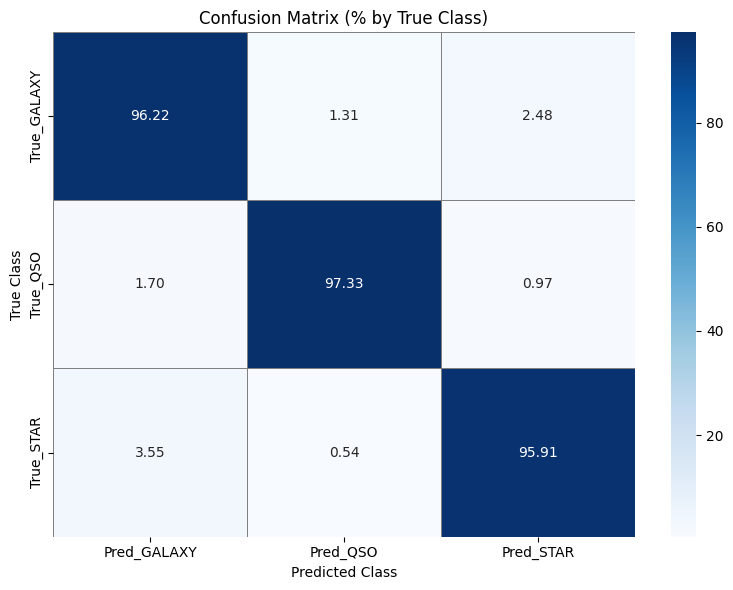

In [3]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")


test_ids = test_df["id"]

X_train = train_df.drop(columns=["id", "class"])
y_train = train_df["class"]

X_test = test_df.drop(columns=["id"])


target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)

class_names = target_encoder.classes_
print("Classes:", class_names)


cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_cols:
  X_train[col] = X_train[col].astype("category")
  X_test[col] = X_test[col].astype("category")


model = LGBMClassifier(
  objective="multiclass",
  num_class=len(class_names),

  n_estimators=2000,
  learning_rate=0.03,
  num_leaves=64,
  max_depth=-1,

  subsample=0.8,
  colsample_bytree=0.8,

  class_weight="balanced",

  random_state=42,
  n_jobs=-1,
  verbose=-1
)

model.fit(
  X_train,
  y_train_encoded,
  categorical_feature=cat_cols
)


test_pred_encoded = model.predict(X_test)
test_pred_labels = target_encoder.inverse_transform(test_pred_encoded.astype(int))


submission = pd.DataFrame({
  "id": test_ids,
  "class": test_pred_labels
})

submission.to_csv("submission.csv", index=False)

print(submission.head())
print("\nSaved submission.csv")

Classes: ['GALAXY' 'QSO' 'STAR']
       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY

Saved submission.csv


# Optuna + LGBM

In [ ]:
import time
import json
import numpy as np
import pandas as pd
import optuna

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

from lightgbm import LGBMClassifier, early_stopping, log_evaluation


df = pd.read_csv("train.csv")
df = df.drop(columns=["id"])

X = df.drop(columns=["class"])
y = df["class"]


target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

class_names = target_encoder.classes_
print("Classes:", class_names)


cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_cols:
  X[col] = X[col].astype("category")


X_train, X_val, y_train, y_val = train_test_split(
  X,
  y_encoded,
  test_size=0.2,
  stratify=y_encoded,
  random_state=42
)


def objective(trial):
  params = {
    "objective": "multiclass",
    "num_class": len(class_names),

    "n_estimators": trial.suggest_int("n_estimators", 500, 4000),
    "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.08, log=True),

    "num_leaves": trial.suggest_int("num_leaves", 16, 256),
    "max_depth": trial.suggest_int("max_depth", 3, 12),
    "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),

    "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    "subsample_freq": 1,
    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

    "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
    "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),

    "class_weight": "balanced",

    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
  }

  model = LGBMClassifier(**params)

  start_time = time.time()

  model.fit(
    X_train,
    y_train,
    categorical_feature=cat_cols,
    eval_set=[(X_val, y_val)],
    eval_metric="multi_logloss",
    callbacks=[
      early_stopping(stopping_rounds=100),
      log_evaluation(period=0)
    ]
  )

  fit_time_sec = time.time() - start_time

  y_pred = model.predict(X_val)

  acc = accuracy_score(y_val, y_pred)

  cm = confusion_matrix(
    y_val,
    y_pred,
    labels=np.arange(len(class_names))
  )

  cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

  trial.set_user_attr("validation_accuracy", acc)
  trial.set_user_attr("fit_time_sec", fit_time_sec)
  trial.set_user_attr("accuracy_per_second", acc / fit_time_sec)
  trial.set_user_attr("confusion_matrix", cm.tolist())
  trial.set_user_attr("confusion_matrix_percent", cm_percent.tolist())
  trial.set_user_attr("best_iteration", model.best_iteration_)

  return acc


study = optuna.create_study(
  study_name="optuna_lgbmclassifier_results",
  direction="maximize",
  storage="sqlite:///optuna_lgbmclassifier_results.db",
  load_if_exists=True
)

study.optimize(
  objective,
  n_trials=10,
  n_jobs=-1
)


print("\nBest trial:")
print(study.best_trial.number)

print("\nBest accuracy:")
print(study.best_value)

print("\nBest parameters:")
print(study.best_params)


results_df = study.trials_dataframe()

results_df.to_csv(
  "optuna_lgbmclassifier_results.csv",
  index=False
)

print("\nSaved to optuna_lgbmclassifier_results.csv")

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Classes: ['GALAXY' 'QSO' 'STAR']


[I 2026-06-16 00:36:06,606] A new study created in RDB with name: optuna_lgbmclassifier_results


Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds
Training until validation scores don't improve for 100 rounds
